In [1]:
# Behzad Ghabaei
# CS 82A - Data Science
# module4_lab3.ipynb
# Textbook Problem 3.2 
# Truck list price vs. best price
# Instructor Seno
# 9/24/2026

#### The truck.csv dataset is a list price vs. best price for a new GMC pickup truck in $1000s.   The attribute X represents the list price, whereas Y represents the best price values.

In [2]:
import pandas as pd
df = pd.read_csv("truck.csv")

In [3]:
df.head(10)

,X,Y
0,12.4,11.2
1,14.3,12.5
2,14.5,12.7
3,14.9,13.1
4,16.1,14.1
5,16.9,14.8
6,16.5,14.4
7,15.4,13.4
8,17.0,14.9
9,17.9,15.6


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       23 non-null     float64
 1   Y       23 non-null     float64
dtypes: float64(2)
memory usage: 500.0 bytes


In [5]:
df.shape

(23, 2)

In [6]:
df.describe()

,X,Y
count,23.000000,23.000000
mean,17.465217,15.300000
std,2.413901,2.057580
min,12.400000,11.200000
25%,15.800000,14.050000
50%,17.299999,15.100000
75%,19.300000,16.849999
max,22.400000,19.600000


#### The average of X at 17.46 and average Y at 15.3.
#### This is an average difference of 2.16.  This is a good indication of the difference between the list price from the best price.

In [7]:
17.46 - 15.30

2.16

#### The list prices X max at 22.4, and the Y best price say max at 19.6.  
#### This is the difference between the max X list price, and max Y best price, 2.79

In [8]:
22.4-19.6

2.799999999999997

#### This is the difference between the min X list price and min Y best price, 1.20

In [9]:
12.4 - 11.2

1.200000000000001

#### This is the difference between the median X list price and median Y best price, 2.09

In [10]:
17.2 - 15.1

2.0999999999999996

## Tutorial:  Center and spread in one line each

In [11]:
df.columns

Index(['X', 'Y'], dtype='str')

In [12]:
print(df["X"].mean())
print(df["X"].median())
print(df["X"].std())


17.465217300434787
17.29999924
2.413900820057722


In [13]:
print(df["Y"].mean())
print(df["Y"].median())
print(df["Y"].std())


15.300000066086955
15.10000038
2.0575803350493964


## Tutorial: Histograms show the shape

<Axes: ylabel='Frequency'>

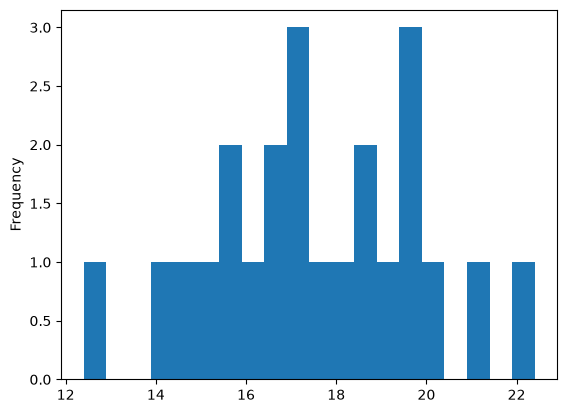

In [14]:
df["X"].plot(kind="hist", bins=20)

#### This histogram shows that the frequency of 17 and 19 are very high and the frequency of 13, 21, 23 are low.  These are the "list" prices.

<Axes: ylabel='Frequency'>

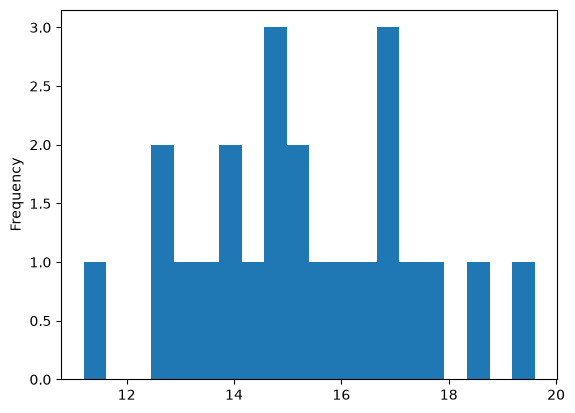

In [15]:
df["Y"].plot(kind="hist", bins=20)

#### The histogram illustrates that 15 and 17 are the most frequent, 11, 19, and 20 are the least frequent for "best" prices.

## Tutorial: The correlation matrix

In [16]:
df.corr(numeric_only=True)


,X,Y
X,1.00000,0.99854
Y,0.99854,1.00000


#### This will determine the Pearson's correlation coefficient between the list price X and best price Y. From the table we can meet a nearly perfect correlation in the wild, meaning that the truck list prices X vs. their actual sale prices (best) Y, with r around 0.9985, can be used to make a defensible numeric prediction.  As the list prices of X increase or decrease the best sale prices Y will also be correlated by an average difference of about 2.16.  If the figure of list price X is around 22 (max) we can anticipate a difference of about 2.79 which makes a best price Y around 19.  If the figure of list price X is low (min) around 12, we can estimate a sale price (best) Y with a difference of around 1, making the best price at around 11.  Correlation alone doesn't provide an indication of how one variable can be predicted from another, but regression can.  
#### Regression predicts an analysis from a predictor variable, with a straight line. The x and y relationship is expressed as:
### ( y = b0 + b1(x) )
#### b1 is the slope of x and b0 is the intercept or error term. b1 and b0 are the data points.
#### The slope of regression is represented with this formula.
### b1 = r stdy / stdx 
#### or the following:
### slope of regression = pearsons coefficient * (the standard deviation of x / the standard deviation of y)
#### value of error calulates as:
### b0 = ( y's mean ) - b1( x's mean )
#### this can help to estimate x and y.
#### Let's try this with our data. To establish a linear regression relationship between list price and best price. 
#### the slope is b1 = Pearson's r * (std of y / std of x ) 

In [17]:
r = 0.99854
std_Y = 2.0575803350493964
std_X = 2.413900820057722
b1 = r * ( std_Y / std_X )
b1

0.8511436139746184

#### error term b0 = y's mean - (slope b1 * x's mean)

In [18]:
Y_mean = 15.300000066086955
X_mean = 17.465217300434787
b0 = Y_mean - ( b1 * X_mean )
b0  # 0.43459189414286215

0.43459189414286215

#### Now we use the regression analysis formula y = mx + b, or y = b0 + b1x
#### Based on the relationship you found, determine the best price of a pickup whose list price X is 25.2 in $1000s

In [19]:
x1 = 25.2
y1 = b0 + (b1 * x1)
y1

21.883410966303245

#### Based on the linear regression analysis, a GMC pickup truck with a list price at \\$25,200 X will be best price Y at \\$21,883

## Tutorial: Scatter plots to eyeball a relationship

<Axes: xlabel='X', ylabel='Y'>

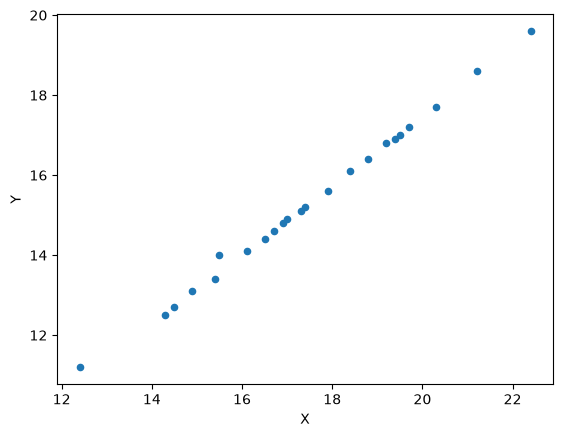

In [20]:
df.plot.scatter(x="X", y="Y")

#### After looking at the scatter plot I can confidently argue that the linear relationship is true and imagining an X coordinate at 25.2 will lie on the Y axis at around 22 or 21.8.  This looks pretty accurate, and sounds correct since looking at the max X and Y difference has a larger difference than the min X and Y difference. (3.39 the current difference, compared to, 2.799 the max difference). The Pearson's correlation coefficient has a nearly perfect positive linear relationship and is powerful. The scatter plot indicates very minimal error and shows predictability to be good. We tried to make an excellent analysis by aggressively comparing any given data.  We predicted that a Causation relationship is present between the X and Y data points. That the X list price causes the Y best price. Regression is a measure of functionality between two or more correlated variables, and the estimated value can be made this way. ( 3.8.1 Regression | "Hands On Intro. to Data Science Using Python | Chirag Shah )

In [21]:
25.2 - 21.8

3.3999999999999986

#### Behzad Ghabaei - End Of Lab